# Data Profile — Book-Crossing

Exploratory profiling of the raw dataset: null rates, explicit/implicit rating split, interactions-per-user and interactions-per-book distributions (bucketed by history depth / popularity), and description coverage.

The report-building logic lives in `src/bxbench/profile.py` (single source of truth for the numbers), so this notebook is for interactive display; the last cell writes the canonical `reports/data_profile.md`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from bxbench.data import load_all
from bxbench.profile import compute_profile, render_markdown

data = load_all()
profile = compute_profile(data["users"], data["books"], data["ratings"], data["descriptions"])
profile["row_counts"]

{'users': 278858, 'books': 271360, 'ratings': 1149780, 'descriptions': 7021}

## Users / Age

In [2]:
print(f"Age null: {profile['age_null_pct']:.1f}%")
print(f"Age implausible (<5 or >100) among non-null: {profile['age_implausible_pct']:.1f}%")
print(f"Age (plausible) mean {profile['age_mean']:.1f}, median {profile['age_median']:.1f}")

Age null: 39.7%
Age implausible (<5 or >100) among non-null: 0.7%
Age (plausible) mean 34.7, median 32.0


## Ratings: explicit vs. implicit

In [3]:
n_total, n_implicit, n_explicit = profile["n_total_ratings"], profile["n_implicit"], profile["n_explicit"]
print(f"implicit (Book-Rating == 0): {n_implicit:,} ({n_implicit/n_total*100:.1f}%)")
print(f"explicit (Book-Rating 1-10): {n_explicit:,} ({n_explicit/n_total*100:.1f}%)")
profile["explicit_dist"]

implicit (Book-Rating == 0): 716,109 (62.3%)
explicit (Book-Rating 1-10): 433,671 (37.7%)


,rating,count,pct_of_explicit
0,1,1770,0.408144
1,2,2759,0.636197
2,3,5996,1.382615
3,4,8904,2.053169
4,5,50974,11.754072
5,6,36924,8.514288
6,7,76457,17.630185
7,8,103736,23.920437
8,9,67541,15.574249
9,10,78610,18.126644


<Axes: title={'center': 'Explicit rating distribution (1-10)'}, xlabel='rating'>

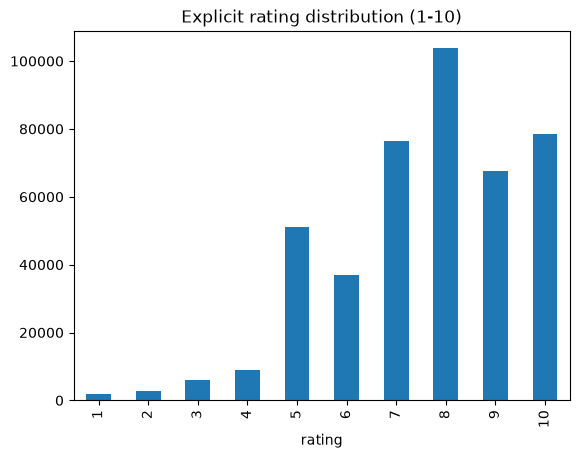

In [4]:
profile["explicit_dist"].plot(x="rating", y="count", kind="bar", legend=False, title="Explicit rating distribution (1-10)")

## Interactions per user (history depth)

In [5]:
print(f"mean {profile['per_user_mean']:.2f}, median {profile['per_user_median']:.0f}, max {profile['per_user_max']:,}")
n_single, n_rated = profile["n_singleton_users"], profile["n_users_rated"]
print(f"users with exactly 1 interaction: {n_single:,} ({n_single/n_rated*100:.1f}%) -- pure cold-start, can't be leave-k-out split")
profile["user_buckets"]

mean 10.92, median 1, max 13,602
users with exactly 1 interaction: 59,166 (56.2%) -- pure cold-start, can't be leave-k-out split


,bucket,n_users,pct
0,1-2,71668,68.071768
1,3-5,13898,13.200612
2,6-20,12639,12.004787
3,21+,7078,6.722833


## Interactions per book (popularity)

In [6]:
print(f"mean {profile['per_book_mean']:.2f}, median {profile['per_book_median']:.0f}, max {profile['per_book_max']:,}")
profile["book_buckets"]

mean 3.38, median 1, max 2,502


,bucket,n_books,pct
0,1-2,256709,75.379380
1,3-5,49090,14.414663
2,6-20,27693,8.131702
3,21+,7064,2.074255


## Description coverage by book popularity bucket

Does description coverage skew toward popular books (which would mean Tier 4's content signal is concentrated where CF already does fine, and least available for the cold-start tail)? Answer: no, roughly flat (~2.3-3.3%) across popularity buckets.

In [7]:
n_desc, n_books = profile["n_desc_in_catalog"], profile["n_books_in_catalog"]
print(f"overall: {n_desc:,} / {n_books:,} ({n_desc/n_books*100:.1f}%)")
profile["coverage_by_bucket"]

overall: 7,021 / 271,360 (2.6%)


,bucket,sum,count,coverage_pct
0,1-2,4647,194078,2.394398
1,3-5,1345,43336,3.103655
2,6-20,862,25874,3.331530
3,21+,167,6863,2.433338


## Write canonical report

In [8]:
report_path = Path.cwd().parent / "reports" / "data_profile.md"
report_path.parent.mkdir(exist_ok=True)
report_path.write_text(render_markdown(profile))
print(f"Wrote {report_path}")

Wrote /Users/patrickcher/Library/CloudStorage/GoogleDrive-patrickcher@gmail.com/My Drive/AI Thoughts/2026-09-book-crossing-personalization-benchmark/reports/data_profile.md
